# # Notebook 01 - Dataset Integration & Quality Audit

Notebook ini adalah tahap pertama setelah proses labelling selesai. Fokusnya adalah menyatukan dan mengaudit hasil label teks dan gambar sebelum masuk ke preprocessing final, split dataset, dan modeling MABSA.

Dataset yang digunakan di Kaggle:
- `text_labelling.csv`
- `image_labelling.csv`

Output notebook disimpan ke:
- `/kaggle/working/mabsa_audit_outputs/`

Catatan penting:
- Notebook ini **tidak mengubah file sumber**.
- Notebook ini hanya membaca dataset labelling, melakukan audit, dan menyimpan laporan hasil audit.
- Path dibuat fleksibel: di Kaggle akan mencari file di `/kaggle/input`, sedangkan saat dijalankan lokal akan fallback ke `G:\Skripsi\Data Labelling`.

## Dasar Metodologi

Alasan notebook audit ini dibuat sebelum training:

1. **ABSA/MABSA membutuhkan label aspek yang konsisten.**
   SemEval ABSA memisahkan prediksi berdasarkan aspek dan polaritas, sehingga validasi label per aspek harus dilakukan sebelum model dilatih.

2. **MABSA rentan terhadap noise antara teks dan gambar.**
   Pada data customer review, gambar yang diunggah belum tentu relevan dengan teks. Paper MABSA modern seperti M2DF membahas bahwa visual context yang tidak relevan bisa menjadi noise dan menurunkan performa model.

3. **Dataset multimodal harus menjaga pasangan text-image.**
   Karena satu review dapat memiliki banyak gambar, kita perlu audit level review dan level image agar tidak terjadi mismatch, duplikasi, atau leakage saat split dataset.

Referensi utama:
- SemEval-2014 Task 4: Aspect Based Sentiment Analysis - https://aclanthology.org/S14-2004/
- Multi-Interactive Memory Network for Aspect Based Multimodal Sentiment Analysis - https://ojs.aaai.org/index.php/AAAI/article/view/3807
- M2DF: Multi-grained Multi-curriculum Denoising Framework for Multimodal Aspect-Based Sentiment Analysis - https://arxiv.org/abs/2310.14605

### 1. Setup Lingkungan, Konstanta, dan Direktori Output


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

ASPECTS = ["Kamar", "Kebersihan", "Pelayanan", "Harga", "Lokasi", "Fasilitas", "Makanan"]
VALID_LABELS = {"Positif", "Negatif", "Netral", "None"}

TEXT_FILE_NAME = "text_labelling.csv"
IMAGE_FILE_NAME = "image_labelling.csv"

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
LOCAL_FALLBACK_DIRS = [
    Path(r"G:\Skripsi\Data Labelling"),
    Path("."),
]

OUTPUT_DIR = Path("/kaggle/working/mabsa_audit_outputs") if Path("/kaggle").exists() else Path("mabsa_audit_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /kaggle/working/mabsa_audit_outputs


### 2. Pencarian Path File Dataset (Teks dan Gambar)


In [2]:
def find_dataset_file(file_name: str) -> Path:
    """Cari file dataset di Kaggle input, lalu fallback ke path lokal."""
    candidates = []

    if KAGGLE_INPUT_ROOT.exists():
        candidates.extend(KAGGLE_INPUT_ROOT.rglob(file_name))

    for base_dir in LOCAL_FALLBACK_DIRS:
        if base_dir.exists():
            direct = base_dir / file_name
            if direct.exists():
                candidates.append(direct)
            candidates.extend(base_dir.rglob(file_name))

    # Hilangkan duplikat sambil menjaga urutan.
    unique_candidates = []
    seen = set()
    for candidate in candidates:
        resolved = str(candidate.resolve()) if candidate.exists() else str(candidate)
        if resolved not in seen:
            seen.add(resolved)
            unique_candidates.append(candidate)

    if not unique_candidates:
        raise FileNotFoundError(
            f"File {file_name!r} tidak ditemukan. "
            "Di Kaggle, pastikan dataset sudah di-add ke notebook dan berisi file ini."
        )

    return unique_candidates[0]

TEXT_PATH = find_dataset_file(TEXT_FILE_NAME)
IMAGE_PATH = find_dataset_file(IMAGE_FILE_NAME)

print("Text dataset :", TEXT_PATH)
print("Image dataset:", IMAGE_PATH)

Text dataset : /kaggle/input/datasets/vince0014/text-labelling/text_labelling.csv
Image dataset: /kaggle/input/datasets/vince0014/image-labelling/image_labelling.csv


### 3. Membaca Dataset dan Normalisasi Kolom Label


In [3]:
def read_csv_str(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, dtype=str, encoding="utf-8-sig").fillna("")
    if "ID_Review" in df.columns:
        df["ID_Review"] = df["ID_Review"].astype(str).str.strip()
    return df

def normalize_label_columns(df: pd.DataFrame, label_columns: list[str]) -> pd.DataFrame:
    # Di CSV final, label None bisa tersimpan sebagai sel kosong.
    # Untuk audit, sel kosong dinormalisasi menjadi None tanpa mengubah file sumber.
    for col in label_columns:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().replace({"": "None"})
    return df

text_df = read_csv_str(TEXT_PATH)
image_df = read_csv_str(IMAGE_PATH)

text_df = normalize_label_columns(text_df, [f"label_{aspect}" for aspect in ASPECTS])
image_df = normalize_label_columns(image_df, ASPECTS)

print("Text shape :", text_df.shape)
print("Image shape:", image_df.shape)

display(text_df.head(3))
display(image_df.head(3))

Text shape : (8038, 14)
Image shape: (17385, 11)


,ID_Review,Platform,Wilayah,Nama_Hotel,Review_Date,Text_Review,label_Kamar,label_Kebersihan,label_Pelayanan,label_Harga,label_Lokasi,label_Fasilitas,label_Makanan,error
0,1,Traveloka,Bandung,Atlantic City Hotel,5/4/2026,"Pesan mendadak hotel di daerah Kota Bandung saat long weekend dan pada penuh, untungnya masih ada kamar tersedia di Hotel Atlantic City. Penyelamat buat ist...",Positif,Positif,Positif,None,Positif,Negatif,Netral,
1,2,Traveloka,Bandung,Atlantic City Hotel,4/18/2026,"Menyenangkan menginap di Hotel Atlantic. Hotel berada di lokasi strategis dekat dengan Istana Plaza, halte transportasi umum, tempat kulineran, dan akses pe...",Positif,Positif,Positif,None,Positif,Negatif,Netral,
2,3,Traveloka,Bandung,Atlantic City Hotel,4/4/2026,"Mantap, oke, dekat dengan semuanya, di lantai bawah ada KFC, Richess 24 jam, semuanya di depan mal, mantap.",None,None,None,None,Positif,None,None,


,ID_Review,Review_Date,Gambar_Ke,Image_FileName,Kamar,Kebersihan,Pelayanan,Harga,Lokasi,Fasilitas,Makanan
0,1,5/4/2026,1,R1_G1_687bd728.jpg,None,Positif,None,None,None,Positif,None
1,2,4/18/2026,1,R2_G1_eb4fea87.jpg,None,None,None,None,Positif,None,None
2,2,4/18/2026,2,R2_G2_3b6a9a2a.jpg,Netral,Netral,None,None,None,None,None


### 4. Pengecekan Ketersediaan Kolom Wajib (Required Columns)


In [4]:
TEXT_REQUIRED_COLUMNS = [
    "ID_Review", "Platform", "Wilayah", "Nama_Hotel", "Review_Date", "Text_Review",
    *[f"label_{aspect}" for aspect in ASPECTS],
]
IMAGE_REQUIRED_COLUMNS = [
    "ID_Review", "Review_Date", "Gambar_Ke", "Image_FileName",
    *ASPECTS,
]

def check_required_columns(df: pd.DataFrame, required_columns: list[str], dataset_name: str) -> list[str]:
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        print(f"[ERROR] Missing columns in {dataset_name}:", missing)
    else:
        print(f"[OK] Semua kolom wajib tersedia di {dataset_name}.")
    return missing

missing_text_columns = check_required_columns(text_df, TEXT_REQUIRED_COLUMNS, "text_labelling.csv")
missing_image_columns = check_required_columns(image_df, IMAGE_REQUIRED_COLUMNS, "image_labelling.csv")

if missing_text_columns or missing_image_columns:
    raise ValueError("Kolom wajib belum lengkap. Perbaiki file dataset sebelum lanjut.")

[OK] Semua kolom wajib tersedia di text_labelling.csv.
[OK] Semua kolom wajib tersedia di image_labelling.csv.


### 5. Ringkasan Informasi Dataset (Baris, Kolom, dan ID Unik)


In [5]:
summary_overview = pd.DataFrame([
    {
        "dataset": "text_labelling",
        "rows": len(text_df),
        "unique_ID_Review": text_df["ID_Review"].nunique(),
        "columns": len(text_df.columns),
        "missing_ID_Review": int((text_df["ID_Review"].str.len() == 0).sum()),
    },
    {
        "dataset": "image_labelling",
        "rows": len(image_df),
        "unique_ID_Review": image_df["ID_Review"].nunique(),
        "columns": len(image_df.columns),
        "missing_ID_Review": int((image_df["ID_Review"].str.len() == 0).sum()),
    },
])

display(summary_overview)

,dataset,rows,unique_ID_Review,columns,missing_ID_Review
0,text_labelling,8038,8038,14,0
1,image_labelling,17385,8038,11,0


### 6. Distribusi Label dan Pengecekan Label Tidak Valid


In [6]:
def label_distribution(df: pd.DataFrame, label_columns: dict[str, str], dataset_name: str) -> pd.DataFrame:
    rows = []
    for aspect, col in label_columns.items():
        counts = df[col].value_counts(dropna=False).to_dict()
        for label in sorted(set(counts) | VALID_LABELS):
            rows.append({
                "dataset": dataset_name,
                "aspect": aspect,
                "label": label,
                "count": int(counts.get(label, 0)),
            })
    return pd.DataFrame(rows)

def invalid_label_rows(df: pd.DataFrame, label_columns: dict[str, str], dataset_name: str) -> pd.DataFrame:
    rows = []
    for aspect, col in label_columns.items():
        mask = ~df[col].isin(VALID_LABELS)
        if mask.any():
            temp = df.loc[mask, ["ID_Review", col]].copy()
            temp["dataset"] = dataset_name
            temp["aspect"] = aspect
            temp = temp.rename(columns={col: "invalid_label"})
            rows.append(temp[["dataset", "ID_Review", "aspect", "invalid_label"]])
    if rows:
        return pd.concat(rows, ignore_index=True)
    return pd.DataFrame(columns=["dataset", "ID_Review", "aspect", "invalid_label"])

text_label_cols = {aspect: f"label_{aspect}" for aspect in ASPECTS}
image_label_cols = {aspect: aspect for aspect in ASPECTS}

text_label_dist = label_distribution(text_df, text_label_cols, "text")
image_label_dist = label_distribution(image_df, image_label_cols, "image")
invalid_text_labels = invalid_label_rows(text_df, text_label_cols, "text")
invalid_image_labels = invalid_label_rows(image_df, image_label_cols, "image")
invalid_labels = pd.concat([invalid_text_labels, invalid_image_labels], ignore_index=True)

print("Invalid label cells:", len(invalid_labels))
display(text_label_dist.pivot(index="aspect", columns="label", values="count").fillna(0).astype(int))
display(image_label_dist.pivot(index="aspect", columns="label", values="count").fillna(0).astype(int))

display(invalid_labels.head(20))

Invalid label cells: 0


label,Negatif,Netral,None,Positif
aspect,,,,
Fasilitas,819,433,5248,1538
Harga,201,168,6853,816
Kamar,1058,428,3898,2654
Kebersihan,964,161,5026,1887
Lokasi,106,144,4951,2837
Makanan,443,559,5071,1965
Pelayanan,394,181,4205,3258


label,Negatif,Netral,None,Positif
aspect,,,,
Fasilitas,14,20,11117,6234
Harga,0,0,17264,121
Kamar,424,3175,10912,2874
Kebersihan,463,3810,2303,10809
Lokasi,0,150,9486,7749
Makanan,4,238,15345,1798
Pelayanan,0,0,16841,544


,dataset,ID_Review,aspect,invalid_label


### 7. Audit Kesesuaian `ID_Review` (Teks Tanpa Gambar & Gambar Tanpa Teks)


In [7]:
# Audit ID match antara dataset teks dan dataset image.
text_ids = set(text_df["ID_Review"])
image_ids = set(image_df["ID_Review"])

text_without_image = sorted(text_ids - image_ids, key=lambda x: int(x) if x.isdigit() else x)
image_without_text = sorted(image_ids - text_ids, key=lambda x: int(x) if x.isdigit() else x)

id_audit = pd.DataFrame([
    {"issue": "text_without_image", "count": len(text_without_image)},
    {"issue": "image_without_text", "count": len(image_without_text)},
])

display(id_audit)
print("Sample text_without_image:", text_without_image[:20])
print("Sample image_without_text:", image_without_text[:20])

,issue,count
0,text_without_image,0
1,image_without_text,0


Sample text_without_image: []
Sample image_without_text: []


### 8. Audit Kesesuaian Tanggal Review (`Review_Date`)


In [8]:
# Audit Review_Date: tanggal di image_labelling harus sama dengan text_labelling untuk ID_Review yang sama.
text_date = text_df[["ID_Review", "Review_Date"]].drop_duplicates("ID_Review").rename(columns={"Review_Date": "Review_Date_text"})
image_date_check = image_df[["ID_Review", "Review_Date", "Image_FileName", "Gambar_Ke"]].merge(text_date, on="ID_Review", how="left")
image_date_check["date_missing_in_text"] = image_date_check["Review_Date_text"].eq("") | image_date_check["Review_Date_text"].isna()
image_date_check["date_mismatch"] = image_date_check["Review_Date"].ne(image_date_check["Review_Date_text"])

date_missing = image_date_check[image_date_check["date_missing_in_text"]].copy()
date_mismatch = image_date_check[~image_date_check["date_missing_in_text"] & image_date_check["date_mismatch"]].copy()

print("Rows with missing Review_Date from text:", len(date_missing))
print("Rows with mismatched Review_Date:", len(date_mismatch))

display(date_missing.head(10))
display(date_mismatch.head(10))

Rows with missing Review_Date from text: 0
Rows with mismatched Review_Date: 0


,ID_Review,Review_Date,Image_FileName,Gambar_Ke,Review_Date_text,date_missing_in_text,date_mismatch


,ID_Review,Review_Date,Image_FileName,Gambar_Ke,Review_Date_text,date_missing_in_text,date_mismatch


### 9. Audit Duplikasi Data dan Ketersediaan Nama File Gambar


In [9]:
# Audit duplikasi.
text_duplicate_id = text_df[text_df.duplicated("ID_Review", keep=False)].sort_values("ID_Review").copy()
image_duplicate_exact = image_df[image_df.duplicated(["ID_Review", "Gambar_Ke", "Image_FileName"], keep=False)].copy()
image_duplicate_gambar_ke = image_df[image_df.duplicated(["ID_Review", "Gambar_Ke"], keep=False)].copy()
image_missing_filename = image_df[image_df["Image_FileName"].str.strip().eq("")].copy()

print("Duplicate text ID rows:", len(text_duplicate_id))
print("Duplicate exact image rows:", len(image_duplicate_exact))
print("Duplicate ID_Review + Gambar_Ke image rows:", len(image_duplicate_gambar_ke))
print("Missing Image_FileName rows:", len(image_missing_filename))

display(text_duplicate_id.head(10))
display(image_duplicate_exact.head(10))
display(image_duplicate_gambar_ke.head(10))
display(image_missing_filename.head(10))

Duplicate text ID rows: 0
Duplicate exact image rows: 0
Duplicate ID_Review + Gambar_Ke image rows: 0
Missing Image_FileName rows: 0


,ID_Review,Platform,Wilayah,Nama_Hotel,Review_Date,Text_Review,label_Kamar,label_Kebersihan,label_Pelayanan,label_Harga,label_Lokasi,label_Fasilitas,label_Makanan,error


,ID_Review,Review_Date,Gambar_Ke,Image_FileName,Kamar,Kebersihan,Pelayanan,Harga,Lokasi,Fasilitas,Makanan


,ID_Review,Review_Date,Gambar_Ke,Image_FileName,Kamar,Kebersihan,Pelayanan,Harga,Lokasi,Fasilitas,Makanan


,ID_Review,Review_Date,Gambar_Ke,Image_FileName,Kamar,Kebersihan,Pelayanan,Harga,Lokasi,Fasilitas,Makanan


### 10. Agregasi Label Gambar dan Penggabungan dengan Dataset Teks


In [10]:
def non_none_aspects_from_row(row: pd.Series, prefix: str) -> set[str]:
    aspects = set()
    for aspect in ASPECTS:
        value = row[f"{prefix}_{aspect}"]
        if isinstance(value, str) and value and value != "None":
            aspects.add(aspect)
    return aspects

def collect_image_labels(series: pd.Series) -> str:
    labels = sorted({value for value in series if value in VALID_LABELS and value != "None"})
    return "|".join(labels) if labels else "None"

# Agregasi label image ke level review.
image_agg_dict = {
    "Gambar_Ke": "count",
    "Image_FileName": lambda x: "|".join(list(x.astype(str))[:10]),
}
for aspect in ASPECTS:
    image_agg_dict[aspect] = collect_image_labels

image_review_agg = image_df.groupby("ID_Review", as_index=False).agg(image_agg_dict)
image_review_agg = image_review_agg.rename(columns={
    "Gambar_Ke": "image_count",
    "Image_FileName": "image_files_sample",
    **{aspect: f"image_{aspect}" for aspect in ASPECTS},
})

text_review = text_df[["ID_Review", "Platform", "Wilayah", "Nama_Hotel", "Review_Date", "Text_Review", *[f"label_{a}" for a in ASPECTS]]].copy()
text_review = text_review.rename(columns={f"label_{aspect}": f"text_{aspect}" for aspect in ASPECTS})

relation_df = text_review.merge(image_review_agg, on="ID_Review", how="outer")
relation_df["image_count"] = relation_df["image_count"].fillna(0).astype(int)
for aspect in ASPECTS:
    relation_df[f"text_{aspect}"] = relation_df[f"text_{aspect}"].fillna("None")
    relation_df[f"image_{aspect}"] = relation_df[f"image_{aspect}"].fillna("None")

relation_df.head(3)

,ID_Review,Platform,Wilayah,Nama_Hotel,Review_Date,Text_Review,text_Kamar,text_Kebersihan,text_Pelayanan,text_Harga,text_Lokasi,text_Fasilitas,text_Makanan,image_count,image_files_sample,image_Kamar,image_Kebersihan,image_Pelayanan,image_Harga,image_Lokasi,image_Fasilitas,image_Makanan
0,1,Traveloka,Bandung,Atlantic City Hotel,5/4/2026,"Pesan mendadak hotel di daerah Kota Bandung saat long weekend dan pada penuh, untungnya masih ada kamar tersedia di Hotel Atlantic City. Penyelamat buat ist...",Positif,Positif,Positif,None,Positif,Negatif,Netral,1,R1_G1_687bd728.jpg,None,Positif,None,None,None,Positif,None
1,10,Traveloka,Bandung,Atlantic City Hotel,1/17/2026,"Diizinkan check-in sebelum jam 12 siang mungkin karena kami dari luar kota, semua staf ramah dan mendapat hadiah voucher makan malam Natal, terima kasih.",None,None,Positif,None,None,None,None,2,R10_G1_8debfff9.jpg|R10_G2_b29ac5d6.jpg,None,Positif,None,None,Positif,None,Positif
2,100,Traveloka,Bandung,Atlantic City Hotel,9/24/2022,"Lokasi strategis. Petugas ramah. Sekuriti top abis, ramah dan pintar memarkirkan mobil, walaupun sempit parkiran di basement, jadi mudah. Makanan rating 7/1...",Netral,Positif,Positif,Positif,Positif,None,Netral,9,R100_G1_3131b00a.jpg|R100_G2_a4e9a23b.jpg|R100_G3_4541d369.jpg|R100_G4_70815ec9.jpg|R100_G5_898c941e.jpg|R100_G6_57cc0cdf.jpg|R100_G7_5a2d3bd7.jpg|R100_G8_e...,Positif,Netral|Positif,Positif,None,Netral|Positif,Positif,None


### 11. Pemetaan Kategori Relasi Sentimen (Teks vs Gambar)


In [11]:
def image_label_set(label_string: str) -> set[str]:
    if not isinstance(label_string, str) or label_string == "None" or not label_string:
        return set()
    return {label for label in label_string.split("|") if label in VALID_LABELS and label != "None"}

def get_text_aspects(row: pd.Series) -> set[str]:
    return {aspect for aspect in ASPECTS if row[f"text_{aspect}"] != "None"}

def get_image_aspects(row: pd.Series) -> set[str]:
    return {aspect for aspect in ASPECTS if row[f"image_{aspect}"] != "None"}

def contradiction_aspects(row: pd.Series) -> list[str]:
    contradictions = []
    for aspect in ASPECTS:
        text_label = row[f"text_{aspect}"]
        image_labels = image_label_set(row[f"image_{aspect}"])
        if text_label == "Positif" and "Negatif" in image_labels:
            contradictions.append(aspect)
        elif text_label == "Negatif" and "Positif" in image_labels:
            contradictions.append(aspect)
    return contradictions

def sentiment_disagreement_aspects(row: pd.Series) -> list[str]:
    disagreements = []
    for aspect in ASPECTS:
        text_label = row[f"text_{aspect}"]
        image_labels = image_label_set(row[f"image_{aspect}"])
        if text_label != "None" and image_labels and text_label not in image_labels:
            disagreements.append(aspect)
    return disagreements

def relation_category(row: pd.Series) -> str:
    text_aspects = get_text_aspects(row)
    image_aspects = get_image_aspects(row)
    shared_aspects = text_aspects & image_aspects
    contradictions = contradiction_aspects(row)

    if not text_aspects and not image_aspects:
        return "both_no_aspect"
    if text_aspects and not image_aspects:
        return "text_aspect_only"
    if image_aspects and not text_aspects:
        return "image_aspect_only"
    if not shared_aspects:
        return "uncorrelated_different_aspects"
    if contradictions:
        return "correlated_but_contradictive"
    return "correlated_non_contradictive"

relation_df["text_aspects"] = relation_df.apply(lambda row: "|".join(sorted(get_text_aspects(row))) or "None", axis=1)
relation_df["image_aspects"] = relation_df.apply(lambda row: "|".join(sorted(get_image_aspects(row))) or "None", axis=1)
relation_df["shared_aspects"] = relation_df.apply(lambda row: "|".join(sorted(get_text_aspects(row) & get_image_aspects(row))) or "None", axis=1)
relation_df["contradiction_aspects"] = relation_df.apply(lambda row: "|".join(contradiction_aspects(row)) or "None", axis=1)
relation_df["sentiment_disagreement_aspects"] = relation_df.apply(lambda row: "|".join(sentiment_disagreement_aspects(row)) or "None", axis=1)
relation_df["relation_category"] = relation_df.apply(relation_category, axis=1)

relation_counts = relation_df["relation_category"].value_counts().rename_axis("relation_category").reset_index(name="count")
relation_counts["percentage"] = (relation_counts["count"] / len(relation_df) * 100).round(2)

display(relation_counts)
display(relation_df[["ID_Review", "Review_Date", "image_count", "text_aspects", "image_aspects", "shared_aspects", "contradiction_aspects", "relation_category"]].head(20))

,relation_category,count,percentage
0,correlated_non_contradictive,4630,57.60
1,uncorrelated_different_aspects,1572,19.56
2,correlated_but_contradictive,1176,14.63
3,image_aspect_only,557,6.93
4,text_aspect_only,85,1.06
5,both_no_aspect,18,0.22


,ID_Review,Review_Date,image_count,text_aspects,image_aspects,shared_aspects,contradiction_aspects,relation_category
0,1,5/4/2026,1,Fasilitas|Kamar|Kebersihan|Lokasi|Makanan|Pelayanan,Fasilitas|Kebersihan,Fasilitas|Kebersihan,Fasilitas,correlated_but_contradictive
1,10,1/17/2026,2,Pelayanan,Kebersihan|Lokasi|Makanan,None,None,uncorrelated_different_aspects
2,100,9/24/2022,9,Harga|Kamar|Kebersihan|Lokasi|Makanan|Pelayanan,Fasilitas|Kamar|Kebersihan|Lokasi|Pelayanan,Kamar|Kebersihan|Lokasi|Pelayanan,None,correlated_non_contradictive
3,1000,3/30/2019,4,Fasilitas|Kamar|Kebersihan|Lokasi|Makanan|Pelayanan,Fasilitas|Kamar|Kebersihan|Lokasi,Fasilitas|Kamar|Kebersihan|Lokasi,Kebersihan,correlated_but_contradictive
4,1001,3/30/2019,2,Lokasi|Makanan|Pelayanan,Fasilitas|Harga|Kebersihan|Lokasi,Lokasi,None,correlated_non_contradictive
5,1002,3/30/2019,2,Lokasi|Makanan|Pelayanan,Kamar|Kebersihan|Lokasi,Lokasi,None,correlated_non_contradictive
6,1003,3/23/2019,2,Lokasi|Makanan,Kamar|Kebersihan|Lokasi,Lokasi,None,correlated_non_contradictive
7,1004,3/23/2019,1,Fasilitas|Kamar|Lokasi|Makanan|Pelayanan,Kamar|Kebersihan,Kamar,None,correlated_non_contradictive
8,1005,3/16/2019,4,Pelayanan,Fasilitas|Kebersihan|Lokasi|Makanan|Pelayanan,Pelayanan,None,correlated_non_contradictive
9,1006,3/9/2019,2,Fasilitas|Harga|Lokasi|Pelayanan,Fasilitas|Kamar|Kebersihan|Lokasi,Fasilitas|Lokasi,None,correlated_non_contradictive


### 12. Inspeksi Sampel Data Berdasarkan Kategori Relasi


In [12]:
# Contoh per kategori untuk inspeksi manual.
example_columns = [
    "ID_Review", "Platform", "Wilayah", "Nama_Hotel", "Review_Date", "image_count",
    "Text_Review", "image_files_sample", "text_aspects", "image_aspects", "shared_aspects",
    "contradiction_aspects", "sentiment_disagreement_aspects", "relation_category",
]

for category in relation_counts["relation_category"].tolist():
    print("=" * 100)
    print(category)
    display(relation_df.loc[relation_df["relation_category"] == category, example_columns].head(5))

correlated_non_contradictive


,ID_Review,Platform,Wilayah,Nama_Hotel,Review_Date,image_count,Text_Review,image_files_sample,text_aspects,image_aspects,shared_aspects,contradiction_aspects,sentiment_disagreement_aspects,relation_category
2,100,Traveloka,Bandung,Atlantic City Hotel,9/24/2022,9,"Lokasi strategis. Petugas ramah. Sekuriti top abis, ramah dan pintar memarkirkan mobil, walaupun sempit parkiran di basement, jadi mudah. Makanan rating 7/1...",R100_G1_3131b00a.jpg|R100_G2_a4e9a23b.jpg|R100_G3_4541d369.jpg|R100_G4_70815ec9.jpg|R100_G5_898c941e.jpg|R100_G6_57cc0cdf.jpg|R100_G7_5a2d3bd7.jpg|R100_G8_e...,Harga|Kamar|Kebersihan|Lokasi|Makanan|Pelayanan,Fasilitas|Kamar|Kebersihan|Lokasi|Pelayanan,Kamar|Kebersihan|Lokasi|Pelayanan,None,Kamar,correlated_non_contradictive
4,1001,Traveloka,Bandung,YELLO Hotel Paskal Bandung,3/30/2019,2,Semuanya baik-baik saja! Satu-satunya hal yang tidak memuaskan hanya tentang spa. Saya ingin mencobanya. Jadi saya menelepon nomor itu dan meminta perawatan...,R1001_G1_bdedd868.jpg|R1001_G2_ae650528.jpg,Lokasi|Makanan|Pelayanan,Fasilitas|Harga|Kebersihan|Lokasi,Lokasi,None,None,correlated_non_contradictive
5,1002,Traveloka,Bandung,YELLO Hotel Paskal Bandung,3/30/2019,2,"staf yang baik dan ramah. Proses check-in dan checkout yang mudah. Lokasi sangat bagus, terhubung dengan Paskal 23 mal. Suasana yang nyaman di lobi dan kama...",R1002_G1_fef49206.jpg|R1002_G2_767c6088.jpg,Lokasi|Makanan|Pelayanan,Kamar|Kebersihan|Lokasi,Lokasi,None,None,correlated_non_contradictive
6,1003,Traveloka,Bandung,YELLO Hotel Paskal Bandung,3/23/2019,2,"Sangat cocok dengan keluarga, dekat dengan Mal, enak banget.",R1003_G1_4e4b1ceb.jpg|R1003_G2_1b6ded51.jpg,Lokasi|Makanan,Kamar|Kebersihan|Lokasi,Lokasi,None,None,correlated_non_contradictive
7,1004,Traveloka,Bandung,YELLO Hotel Paskal Bandung,3/23/2019,1,Memuaskan! Awalnya sempat agak ragu juga karena liat beberapa review yang ga bagus tentang Yello. Tapi semua ga terbukti pas aku sama keluarga menginap 1 ma...,R1004_G1_dfe2be74.jpg,Fasilitas|Kamar|Lokasi|Makanan|Pelayanan,Kamar|Kebersihan,Kamar,None,Kamar,correlated_non_contradictive


uncorrelated_different_aspects


,ID_Review,Platform,Wilayah,Nama_Hotel,Review_Date,image_count,Text_Review,image_files_sample,text_aspects,image_aspects,shared_aspects,contradiction_aspects,sentiment_disagreement_aspects,relation_category
1,10,Traveloka,Bandung,Atlantic City Hotel,1/17/2026,2,"Diizinkan check-in sebelum jam 12 siang mungkin karena kami dari luar kota, semua staf ramah dan mendapat hadiah voucher makan malam Natal, terima kasih.",R10_G1_8debfff9.jpg|R10_G2_b29ac5d6.jpg,Pelayanan,Kebersihan|Lokasi|Makanan,None,None,None,uncorrelated_different_aspects
14,1010,Traveloka,Bandung,YELLO Hotel Paskal Bandung,2/16/2019,1,"Hotelnya bagus, minimalis dan milenial, letaknya strategis di atas mal, banyak jajanan. Cocok buat yang pengen ke Bandung tapi tidak mau susah. Stafnya juga...",R1010_G1_6e5ae5a3.jpg,Lokasi|Pelayanan,Fasilitas|Kebersihan,None,None,None,uncorrelated_different_aspects
18,1014,Traveloka,Bandung,YELLO Hotel Paskal Bandung,2/9/2019,2,Hampir sempurna 👌 kecuali wi-fi tidak dapat mengunduh Netflix,R1014_G1_b9fa3271.jpg|R1014_G2_272d9d83.jpg,Fasilitas,Kamar|Kebersihan,None,None,None,uncorrelated_different_aspects
26,1021,Traveloka,Bandung,YELLO Hotel Paskal Bandung,1/26/2019,1,"bagus place to menginap, minusnya tidak ada pengering rambut.",R1021_G1_003ffe7f.jpg,Fasilitas,Kamar|Kebersihan,None,None,None,uncorrelated_different_aspects
27,1022,Traveloka,Bandung,YELLO Hotel Paskal Bandung,1/26/2019,2,Sudah sering menginap disini dan pasti akan kembali kesini lagi. Pelayanan memuaskan. Terima kasih.,R1022_G1_c0e3a77d.jpg|R1022_G2_89e0fcac.jpg,Pelayanan,Fasilitas|Kebersihan,None,None,None,uncorrelated_different_aspects


correlated_but_contradictive


...

,ID_Review,Platform,Wilayah,Nama_Hotel,Review_Date,image_count,Text_Review,image_files_sample,text_aspects,image_aspects,shared_aspects,contradiction_aspects,sentiment_disagreement_aspects,relation_category
21,1017,Traveloka,Bandung,YELLO Hotel Paskal Bandung,2/2/2019,3,secara keseluruhan bagus.,R1017_G1_27335bd0.jpg|R1017_G2_c9022ebf.jpg|R1017_G3_66ca352a.jpg,None,Fasilitas|Kebersihan|Lokasi,None,None,None,image_aspect_only
79,107,Traveloka,Bandung,Atlantic City Hotel,2/19/2022,1,Sangat sesuai dengan gambar yang ditawarkan,R107_G1_c6033b5d.jpg,None,Kamar|Kebersihan,None,None,None,image_aspect_only
103,1091,Traveloka,Bandung,YELLO Hotel Paskal Bandung,10/6/2018,1,Semuanya memuaskan dan menyenangkan.,R1091_G1_6471e90d.jpg,None,Fasilitas|Kebersihan,None,None,None,image_aspect_only
143,1127,Traveloka,Bandung,YELLO Hotel Paskal Bandung,6/30/2018,3,Tempat nyaman untuk liburan keluarga,R1127_G1_e8a04a0a.jpg|R1127_G2_e9941f48.jpg|R1127_G3_0351cf73.jpg,None,Fasilitas|Kamar|Kebersihan|Lokasi,None,None,None,image_aspect_only
145,1129,Traveloka,Bandung,YELLO Hotel Paskal Bandung,6/30/2018,2,"Baguss, nyaman, keren dan unik. Masukan aja mohon di sediakan tissue di kamar/di meja makan, karena saya tidak lihat tissue wajah di kanar/meja makan.",R1129_G1_c8bf0a2c.jpg|R1129_G2_225b9198.jpg,None,Fasilitas|Kebersihan|Lokasi,None,None,None,image_aspect_only


text_aspect_only


,ID_Review,Platform,Wilayah,Nama_Hotel,Review_Date,image_count,Text_Review,image_files_sample,text_aspects,image_aspects,shared_aspects,contradiction_aspects,sentiment_disagreement_aspects,relation_category
37,1031,Traveloka,Bandung,YELLO Hotel Paskal Bandung,1/12/2019,1,"Hotel ini dekat banget sama stasiun dan mal, Dudah kami yang dari jogja naik kereta sampai hotel bisa istirahat sebentar dan cari makan malam tidak jauh dar...",R1031_G1_54f07777.jpg,Harga|Kamar|Kebersihan|Lokasi|Makanan|Pelayanan,None,None,None,None,text_aspect_only
80,1070,Traveloka,Bandung,YELLO Hotel Paskal Bandung,12/1/2018,1,"Saya tidak dapat menggambarkannya, tempat ini luar biasa dan sangat dekat dari tempat umum, restoran, film, pusat perbelanjaan, hanya berjalan kaki 😍😘",R1070_G1_51bd42ab.jpg,Lokasi,None,None,None,None,text_aspect_only
133,1118,Traveloka,Bandung,YELLO Hotel Paskal Bandung,7/21/2018,1,"Hotelnya bersih, interior bagus. Letaknya strategis di bawahnya ada mal dan dekat tempat makan. Kalau ke Bandung saya akan menginap lagi di Yello Hotel.",R1118_G1_29974871.jpg,Kebersihan|Lokasi,None,None,None,None,text_aspect_only
597,1536,Traveloka,Bandung,ibis Bandung Trans Studio,6/28/2025,1,Hotelnya bagus dan bersih. Ada masjid besar di seberang lobi hotel. Ada banyak restoran dan kedai kopi yang bisa ditempuh dengan berjalan kaki beberapa menit.,R1536_G1_1de3968c.jpg,Kebersihan|Lokasi,None,None,None,None,text_aspect_only
877,1789,Traveloka,Bandung,ibis Bandung Trans Studio,2/2/2019,3,"Ibis Bandung Trans Studio telah menyelesaikan akhir pekan kami 👏🏻💝😍 hal terbaik yang kami suka adalah hotel ini bersih, nyaman dan nyaman👍 Terima kasih Ibis...",R1789_G1_640e0df4.jpg|R1789_G2_dc0d629c.jpg|R1789_G3_5ad707e4.jpg,Kamar|Kebersihan,None,None,None,None,text_aspect_only


both_no_aspect


,ID_Review,Platform,Wilayah,Nama_Hotel,Review_Date,image_count,Text_Review,image_files_sample,text_aspects,image_aspects,shared_aspects,contradiction_aspects,sentiment_disagreement_aspects,relation_category
566,1508,Traveloka,Bandung,ibis Bandung Trans Studio,11/1/2025,1,"sangat mengesankan sekali,kami sekeluarga sangat senang menginap di Ibis hotel Bandung",R1508_G1_c1e35fa8.jpg,None,None,None,None,None,both_no_aspect
1985,2786,Traveloka,Bogor,Whiz Prime Hotel Pajajaran Bogor,10/4/2025,1,"Saya yang pesan hotelnya, saya yang membayar, tetapi teman-teman saya yang menginap di sana, info dari mereka yang menginap hotelnya bagus.",R2786_G1_1699b0e4.jpg,None,None,None,None,None,both_no_aspect
1986,2787,Traveloka,Bogor,Whiz Prime Hotel Pajajaran Bogor,10/4/2025,1,"Saya yang pesan, saya yang bayar, dan teman-teman saya yang menginap di sana, tapi info dari mereka hotelnya bagus. O.k, pokoknya",R2787_G1_fbf3f5b0.jpg,None,None,None,None,None,both_no_aspect
5269,5743,Traveloka,Subang,favehotel Pamanukan,11/19/2022,1,#NAME?,R5743_G1_18f62573.jpg,None,None,None,None,None,both_no_aspect
5522,5971,Tiket,Bandung,Hay Bandung,9/26/2025,1,Bukan saya yang menginap tapi tidak ada komplain,R5971_G1_e9476db2.jpg,None,None,None,None,None,both_no_aspect


### 13. Pengecekan Keberadaan File Fisik Gambar (Opsional)


In [13]:
# Optional: cek keberadaan file gambar di Kaggle input.
# Matikan default-nya agar notebook tetap cepat. Aktifkan jika dataset Kaggle juga berisi folder gambar.
CHECK_IMAGE_FILE_EXISTENCE = False

if CHECK_IMAGE_FILE_EXISTENCE:
    image_extensions = {".jpg", ".jpeg", ".png", ".webp"}
    search_roots = []
    if KAGGLE_INPUT_ROOT.exists():
        search_roots.append(KAGGLE_INPUT_ROOT)
    for base_dir in LOCAL_FALLBACK_DIRS:
        if base_dir.exists():
            search_roots.append(base_dir)

    file_index = {}
    for root in search_roots:
        for file_path in root.rglob("*"):
            if file_path.suffix.lower() in image_extensions:
                file_index.setdefault(file_path.name, file_path)

    image_df["image_file_exists"] = image_df["Image_FileName"].map(lambda name: name in file_index)
    missing_image_files = image_df[~image_df["image_file_exists"]].copy()

    print("Indexed image files:", len(file_index))
    print("Missing image files:", len(missing_image_files))
    display(missing_image_files.head(20))
else:
    missing_image_files = pd.DataFrame(columns=image_df.columns.tolist() + ["image_file_exists"])
    print("Image file existence check dilewati. Set CHECK_IMAGE_FILE_EXISTENCE = True jika ingin mengecek file gambar fisik.")

Image file existence check dilewati. Set CHECK_IMAGE_FILE_EXISTENCE = True jika ingin mengecek file gambar fisik.


### 14. Penyimpanan Seluruh Laporan Hasil Audit (CSV & JSON)


In [14]:
# Simpan semua laporan audit ke output folder.
text_label_dist.to_csv(OUTPUT_DIR / "text_label_distribution.csv", index=False, encoding="utf-8-sig")
image_label_dist.to_csv(OUTPUT_DIR / "image_label_distribution.csv", index=False, encoding="utf-8-sig")
invalid_labels.to_csv(OUTPUT_DIR / "invalid_labels.csv", index=False, encoding="utf-8-sig")
relation_df.to_csv(OUTPUT_DIR / "review_relation_audit.csv", index=False, encoding="utf-8-sig")
relation_counts.to_csv(OUTPUT_DIR / "relation_category_counts.csv", index=False, encoding="utf-8-sig")

pd.DataFrame({"ID_Review": text_without_image}).to_csv(OUTPUT_DIR / "text_without_image.csv", index=False, encoding="utf-8-sig")
pd.DataFrame({"ID_Review": image_without_text}).to_csv(OUTPUT_DIR / "image_without_text.csv", index=False, encoding="utf-8-sig")
text_duplicate_id.to_csv(OUTPUT_DIR / "duplicate_text_id_rows.csv", index=False, encoding="utf-8-sig")
image_duplicate_exact.to_csv(OUTPUT_DIR / "duplicate_exact_image_rows.csv", index=False, encoding="utf-8-sig")
image_duplicate_gambar_ke.to_csv(OUTPUT_DIR / "duplicate_image_gambar_ke_rows.csv", index=False, encoding="utf-8-sig")
image_missing_filename.to_csv(OUTPUT_DIR / "missing_image_filename_rows.csv", index=False, encoding="utf-8-sig")
date_missing.to_csv(OUTPUT_DIR / "missing_review_date_from_text.csv", index=False, encoding="utf-8-sig")
date_mismatch.to_csv(OUTPUT_DIR / "review_date_mismatch_rows.csv", index=False, encoding="utf-8-sig")
missing_image_files.to_csv(OUTPUT_DIR / "missing_physical_image_files.csv", index=False, encoding="utf-8-sig")

summary = {
    "text_rows": int(len(text_df)),
    "text_unique_ID_Review": int(text_df["ID_Review"].nunique()),
    "image_rows": int(len(image_df)),
    "image_unique_ID_Review": int(image_df["ID_Review"].nunique()),
    "invalid_label_cells": int(len(invalid_labels)),
    "text_without_image_count": int(len(text_without_image)),
    "image_without_text_count": int(len(image_without_text)),
    "duplicate_text_id_rows": int(len(text_duplicate_id)),
    "duplicate_exact_image_rows": int(len(image_duplicate_exact)),
    "duplicate_image_gambar_ke_rows": int(len(image_duplicate_gambar_ke)),
    "missing_image_filename_rows": int(len(image_missing_filename)),
    "missing_review_date_from_text_rows": int(len(date_missing)),
    "review_date_mismatch_rows": int(len(date_mismatch)),
    "relation_category_counts": relation_counts.set_index("relation_category")["count"].to_dict(),
}

with open(OUTPUT_DIR / "audit_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Audit outputs saved to:", OUTPUT_DIR)
print(json.dumps(summary, ensure_ascii=False, indent=2))

Audit outputs saved to: /kaggle/working/mabsa_audit_outputs
{
  "text_rows": 8038,
  "text_unique_ID_Review": 8038,
  "image_rows": 17385,
  "image_unique_ID_Review": 8038,
  "invalid_label_cells": 0,
  "text_without_image_count": 0,
  "image_without_text_count": 0,
  "duplicate_text_id_rows": 0,
  "duplicate_exact_image_rows": 0,
  "duplicate_image_gambar_ke_rows": 0,
  "missing_image_filename_rows": 0,
  "missing_review_date_from_text_rows": 0,
  "review_date_mismatch_rows": 0,
  "relation_category_counts": {
    "correlated_non_contradictive": 4630,
    "uncorrelated_different_aspects": 1572,
    "correlated_but_contradictive": 1176,
    "image_aspect_only": 557,
    "text_aspect_only": 85,
    "both_no_aspect": 18
  }
}


### 15. Visualisasi Distribusi Kategori Relasi Text-Image


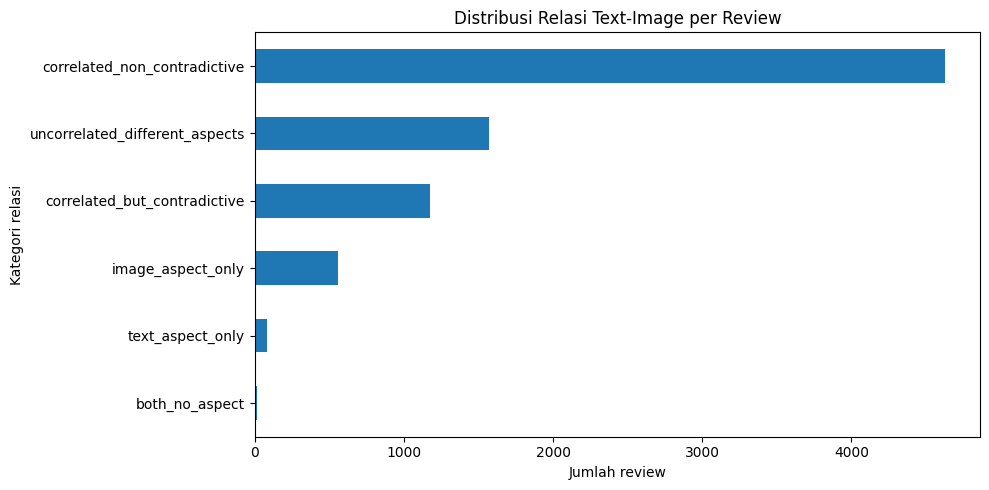

In [15]:
# Visual ringkas untuk distribusi kategori relasi text-image.
try:
    import matplotlib.pyplot as plt

    ax = relation_counts.sort_values("count").plot(
        kind="barh",
        x="relation_category",
        y="count",
        figsize=(10, 5),
        legend=False,
        title="Distribusi Relasi Text-Image per Review",
    )
    ax.set_xlabel("Jumlah review")
    ax.set_ylabel("Kategori relasi")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("Visualisasi dilewati karena error:", exc)

### 16. Checklist Akhir Pengecekan Isu Kritis Dataset


In [16]:
# Checklist akhir: jika semua nilai kritis 0, dataset siap masuk Notebook 02.
critical_checks = pd.DataFrame([
    {"check": "invalid_label_cells", "value": len(invalid_labels), "expected": 0},
    {"check": "text_without_image", "value": len(text_without_image), "expected": 0},
    {"check": "image_without_text", "value": len(image_without_text), "expected": 0},
    {"check": "missing_review_date_from_text", "value": len(date_missing), "expected": 0},
    {"check": "review_date_mismatch", "value": len(date_mismatch), "expected": 0},
    {"check": "missing_image_filename", "value": len(image_missing_filename), "expected": 0},
])
critical_checks["status"] = np.where(critical_checks["value"] == critical_checks["expected"], "OK", "NEEDS_REVIEW")

display(critical_checks)

if (critical_checks["status"] == "NEEDS_REVIEW").any():
    print("Ada isu kritis yang perlu dicek sebelum lanjut ke notebook berikutnya.")
    print("Untuk aturan dataset MABSA text+image, baris text_without_image biasanya perlu dikeluarkan pada final dataset builder.")
else:
    print("Audit kritis aman. Dataset siap lanjut ke Notebook 02: multimodal relation taxonomy / final dataset builder.")

,check,value,expected,status
0,invalid_label_cells,0,0,OK
1,text_without_image,0,0,OK
2,image_without_text,0,0,OK
3,missing_review_date_from_text,0,0,OK
4,review_date_mismatch,0,0,OK
5,missing_image_filename,0,0,OK


Audit kritis aman. Dataset siap lanjut ke Notebook 02: multimodal relation taxonomy / final dataset builder.
